<H1>Bayesian Linear Model Using Using TensorFlow Probability</H1>

Classic frequentist linear regression modeling generally involves estimating the parameters $\beta$ and $\sigma$ of a linear model using various methods such as ordinary least squares.<br>




$\hat{y_{i}}\sim\mathcal{N}(\hat{\beta} X ,]\hat{\sigma}^{2}I)$<br>

$P(Y_{i}=y_{i}|X_{i}=x_{i}, \beta=\hat{\beta}, \sigma=\hat{\sigma}^{2})$<br>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import tensorflow as tf
import tensorflow_probability as tfp

print('TF version:', tf.__version__)
print('TFP version:', tfp.__version__)

2025-08-17 01:10:28.552850: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-17 01:10:28.587040: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.20.0
TFP version: 0.25.0


<H1>1) Data Generation</H1>

Create a training set that reprents the following function:<br>
$$\large y_{i}=x_{i}+\text{c}\epsilon_{i}\quad\quad\quad\text{where c }\in\left(0, 1\right]\text{ and }\epsilon\sim\mathcal{N}\left(0,\sigma^{2}\right)$$

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_365338/1257704142.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.text(-1., 4, f'$y = x * {desired_slope} + {c} * \epsilon$',


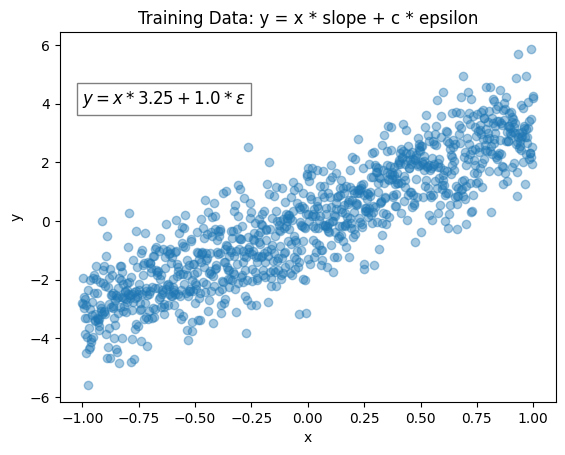

In [3]:
# Create and plot training data
# Set the desired slope
desired_slope = 3.25
# Set number of samples we want in our training data set
num_training_samples = 1000
x_train = np.linspace(-1, 1, 1000)[:, np.newaxis]
# Set a constant c to scale the noise from epsilon
c = 1. 
# Generate dependent variable y as a function of the training data x
y_train = x_train * desired_slope + c * np.random.randn(num_training_samples)[:, np.newaxis]

plt.scatter(x_train, y_train, alpha=0.4)
plt.title('Training Data: y = x * slope + c * epsilon')
plt.xlabel('x')
plt.ylabel('y')
plt.text(-1., 4, f'$y = x * {desired_slope} + {c} * \epsilon$',
                       fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='black')) 
plt.show()

<H1>2) Configure the linear regression model</H1>

Let $n$ be the number of training samples and $m$ be the number of features in the training data.

Classic frequentist regression linear regression models formulate the problem as follows:<br>


$$\large\underset{\left(nx1\right)}{Y}=\begin{pmatrix}
y_{0} \\
y_{1} \\
\vdots \\
y_{n-1} \end{pmatrix}, 

\quad\underset{\left(nxm\right)}{X}=\left[\begin{matrix}
x_{0,0} & x_{0,11} &\dots &x_{0,m-1} \\
x_{1,0} & x_{1,1} &\dots &x_{1,m-1} \\
\vdots & \dots & \ddots & \vdots\\
x_{n-1,0} & \dots & \dots &x_{N-1, m-1}
\end{matrix}\right],

\quad\underset{\left(Nx1\right)}{\epsilon}=\begin{pmatrix}
\epsilon_{0} \\
\epsilon_{1} \\
\vdots \\
\epsilon_{n-1} \end{pmatrix}$$

$$\large\epsilon\sim\mathcal{N}\left(\mu,\sigma^{2}I\right)$$
$$\large Y=\mathop{\mathbb{E}}\left[Y|X,\beta\right]+\epsilon$$
$$\large Y=X\beta+\epsilon$$
$$\large\hat{Y}=X\hat{\beta}$$
where<br>
$$\large\beta=\begin{pmatrix}
\beta_{0} \\
\beta_{1} \\
\vdots \\
\beta_{m} \end{pmatrix}$$
and<br>
$$\large\hat{\beta}=\begin{pmatrix}
\hat{\beta}_{0} \\
\hat{\beta}_{1} \\
\vdots \\
\hat{\beta}_{m} \end{pmatrix}$$

In [4]:
# Set the input shape
input_shape = (x_train.shape[1],)
# Create a dense Keras model along with a distribution layer that outputs a normal 
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=2, input_shape=input_shape, activation='linear'),
    tfp.layers.DistributionLambda(lambda t: tfp.distributions.Independent(tfp.distributions.Normal(loc=t[..., :1], scale=tf.math.softplus(t[..., 1:]))))
])

Instructions for updating:
Please pass an integer value for `reinterpreted_batch_ndims`. The current behavior corresponds to `reinterpreted_batch_ndims=tf.size(distribution.batch_shape_tensor()) - 1`.


I0000 00:00:1755393030.270773  365338 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10393 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:02:00.0, compute capability: 8.6


$\large\quad\text{Define the loss function}$<br>

Minimizing the negative log-likelihood of the learned distribution 

In [5]:
# Define the negative log likelihood cost function
def nll(x_train, distribution):
    return -tf.reduce_sum(distribution.log_prob(x_train))

<H1>3) Learn estimates for the model parameter(s)</H1>

In [6]:
# Instantiate an optimizer
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.005)
model.compile(loss=nll, optimizer=optimizer)
model.summary()
model.fit(x_train, y_train, epochs=10000, verbose=False)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 4         
                                                                 
 distribution_lambda (Distr  ((None, 1),               0         
 ibutionLambda)               (None, 1))                         
                                                                 
Total params: 4 (16.00 Byte)
Trainable params: 4 (16.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2025-08-17 01:10:31.417586: I external/local_xla/xla/service/service.cc:163] XLA service 0x757ab5d8c930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-17 01:10:31.417599: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-08-17 01:10:31.421418: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-08-17 01:10:31.427181: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90701
I0000 00:00:1755393031.458112  365481 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


<H1>4) Make predictions on the training data.</H1>

In [7]:
# Make predictions.
yhat = model(x_train)
yhat_mean = yhat.mean()
yhat_std = yhat.stddev()



<H1>5) Compute trained prediction model metrics.</H1>

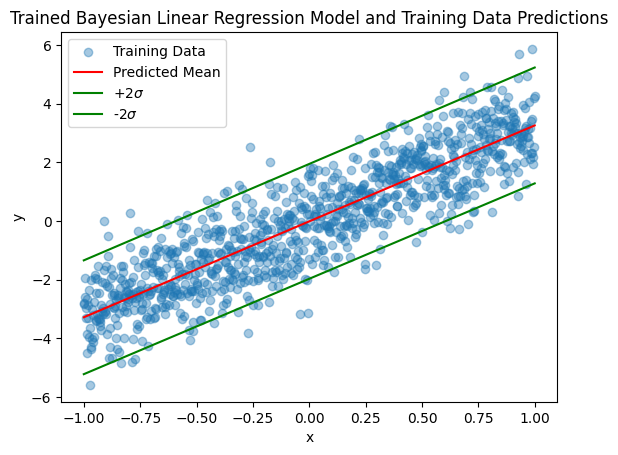

In [8]:
# Plot the training data and the model predictions
plt.scatter(x_train, y_train, alpha=0.4, label='Training Data')
plt.plot(x_train, yhat_mean, color='red', label='Predicted Mean')
plt.plot(x_train, yhat_mean+2*yhat_std, color='green', label=r'+2$\sigma$')
plt.plot(x_train, yhat_mean-2*yhat_std, color='green', label=r'-2$\sigma$')
plt.title('Trained Bayesian Linear Regression Model and Training Data Predictions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()



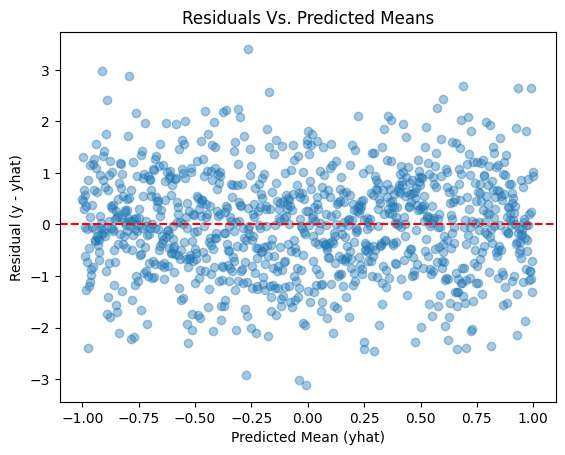

In [9]:
# Plot the residuals
residuals = y_train - yhat_mean
plt.scatter(x_train, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Vs. Predicted Means')
plt.xlabel('Predicted Mean (yhat)')
plt.ylabel('Residual (y - yhat)')
plt.show()

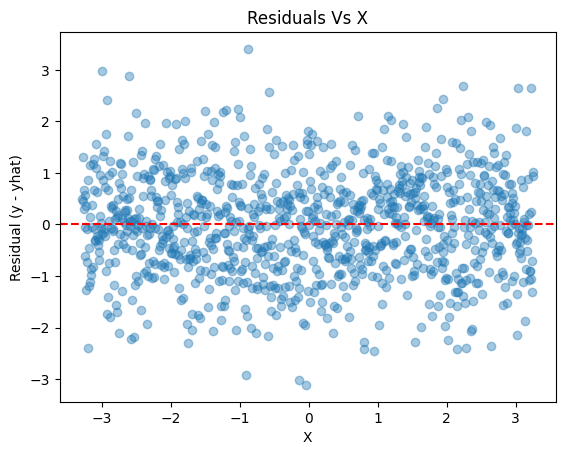

In [10]:
# Scatter Plot residuals vs predicitons
# Plot the residuals
residuals = y_train - yhat_mean
plt.scatter(yhat_mean, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Vs X')
plt.xlabel('X')
plt.ylabel('Residual (y - yhat)')
plt.show()

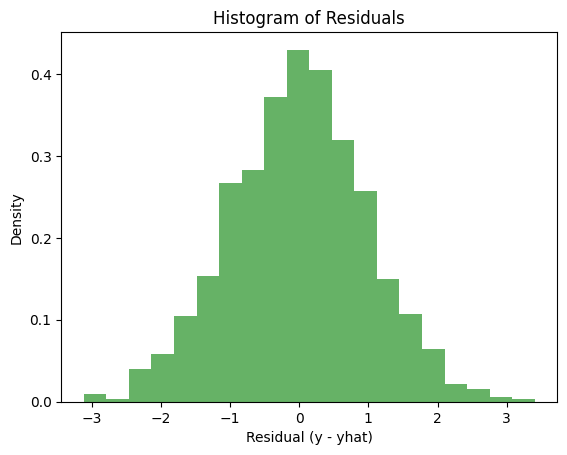

In [11]:
# Plot historgram of residuals
plt.hist(residuals, bins=20, density=True, alpha=0.6, color='g')
plt.title('Histogram of Residuals')
plt.xlabel('Residual (y - yhat)')
plt.ylabel('Density')
plt.show()  

<H1>References</H1>

1.) Kutner M., Nachtsheim C., Neter J., "Applied Linear Regression Models", McGraw3-Hill Irwin, 4th ed, 2004. 